   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker  

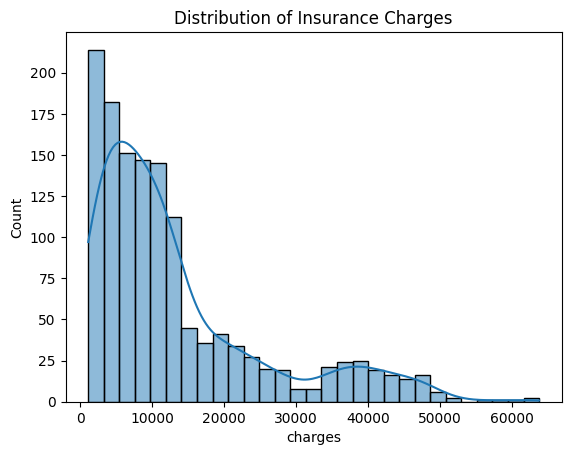

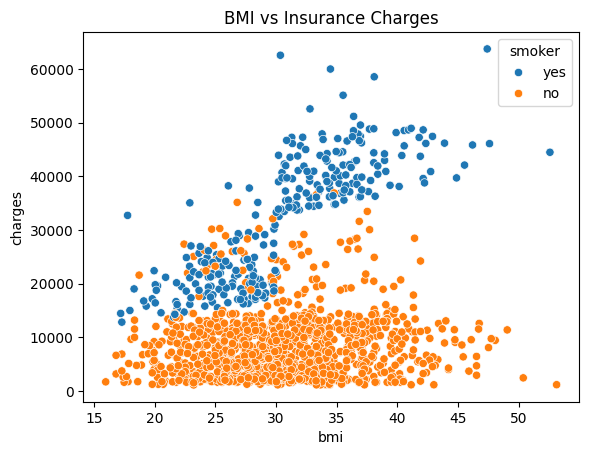

               Model          MAE          RMSE        R2
0  Linear Regression  4177.045561   5956.342894  0.806929
1      Random Forest  2586.373908   4678.877462  0.880864
2  Gradient Boosting  2535.062045   4271.894268  0.900689
3                SVR  9260.280186  14425.336625 -0.132427


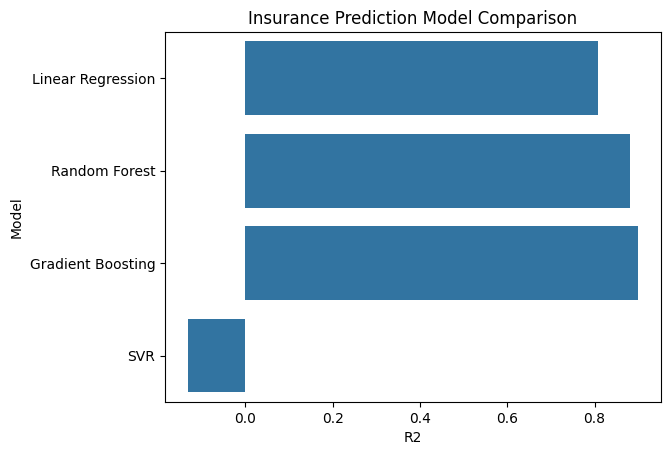

MEDICAL INSURANCE PREDICTION COMPLETED


In [2]:
# ============================================
# MEDICAL INSURANCE PRICE PREDICTION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================
# Load Dataset
# ============================================

data = pd.read_csv("insurance.csv")

print(data.head())
print(data.shape)
print(data.info())


# ============================================
# Check Data
# ============================================

print("\nMissing Values:")
print(data.isnull().sum())

print(
    "\nDuplicates:",
    data.duplicated().sum()
)

data.drop_duplicates(
    inplace=True
)


# ============================================
# EDA
# ============================================

sns.histplot(
    data["charges"],
    kde=True
)

plt.title(
    "Distribution of Insurance Charges"
)

plt.show()


sns.scatterplot(
    data=data,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.title(
    "BMI vs Insurance Charges"
)

plt.show()


# ============================================
# Features and Target
# ============================================

X = data.drop(
    "charges",
    axis=1
)

y = data["charges"]


categorical_columns = (
    X.select_dtypes(
        include="object"
    ).columns
)

numerical_columns = (
    X.select_dtypes(
        exclude="object"
    ).columns
)


# ============================================
# Preprocessing
# ============================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numerical_columns
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)


# ============================================
# Train Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ============================================
# Models
# ============================================

models = {

    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        ),

    "SVR":
        SVR()
}


# ============================================
# Train Models
# ============================================

results = []

for name, model in models.items():

    pipeline = Pipeline([

        (
            "preprocessing",
            preprocessor
        ),

        (
            "model",
            model
        )
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    prediction = pipeline.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    r2 = r2_score(
        y_test,
        prediction
    )

    results.append(
        [
            name,
            mae,
            rmse,
            r2
        ]
    )


# ============================================
# Results
# ============================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

print(results_df)


sns.barplot(
    data=results_df,
    x="R2",
    y="Model"
)

plt.title(
    "Insurance Prediction Model Comparison"
)

plt.show()


print(
    "MEDICAL INSURANCE PREDICTION COMPLETED"
)